<a href="https://colab.research.google.com/github/Jago56/Andre_pyt_calculator/blob/main/netflix_data_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#import the data set
import pandas as pd
import numpy as np


In [ ]:
# dataset
df = pd.read_csv("/netflix.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
#info of the data
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


we have checkes the data added data type - it is object but is should be date/time dataype -- so we must clean

Agenda
- Data Cleaing
- Data Analysi/conditional analysis
- Data Visualization
- Visualizationn - wordcloud

check null values

In [ ]:
df.isnull().sum

<bound method DataFrame.sum of       show_id   type  title  director   cast  country  date_added  \
0       False  False  False     False   True    False       False   
1       False  False  False      True  False    False       False   
2       False  False  False     False  False     True       False   
3       False  False  False      True   True     True       False   
4       False  False  False      True  False    False       False   
...       ...    ...    ...       ...    ...      ...         ...   
8802    False  False  False     False  False    False       False   
8803    False  False  False      True   True     True       False   
8804    False  False  False     False  False    False       False   
8805    False  False  False     False  False    False       False   
8806    False  False  False     False  False    False       False   

      release_year  rating  duration  listed_in  description  
0            False   False     False      False        False  
1            False   False     False      False        False  
2            False   False     False      False        False  
3            False   False     False      False        False  
4            False   False     False      False        False  
...            ...     ...       ...        ...          ...  
8802         False   False     False      False        False  
8803         False   False     False      False        False  
8804         False   False     False      False        False  
8805         False   False     False      False        False  
8806         False   False     False      False        False  

[8807 rows x 12 columns]>

In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


here the number of missing values in the DIR column is high.  As such, we will drop the column and save in a new variable

In [ ]:
# save in the new variable
director = df[['director']]

In [ ]:
director.head()

,director
0,Kirsten Johnson
1,NaN
2,Julien Leclercq
3,NaN
4,NaN


remove the column for the original dataset

In [ ]:
df = df.drop(columns = ['director'])

In [ ]:
df.columns

Index(['show_id', 'type', 'title', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3
listed_in,0


In [ ]:
# drop the null values from country and date added
df = df.dropna()

In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0
listed_in,0


check how many movies and TV shows are in dataset

In [ ]:
df['type'].value_counts()

,count
type,
Movie,5277
TV Show,2013


In [ ]:
#how many countries movies and tv shows

In [ ]:
df['country'].value_counts()

,count
country,
United States,2479
India,940
United Kingdom,350
Japan,238
South Korea,196
...,...
"South Korea, Canada, United States, China",1
"Argentina, Uruguay, Serbia",1
"France, Japan",1


changing the data type of date_added

In [ ]:
df.columns

Index(['show_id', 'type', 'title', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [ ]:
df['date_added'] = pd.to_datetime(df['date_added'], errors = 'coerce')

In [ ]:
df.date_added.dtype

dtype('O')

In [ ]:
df.dtypes

,0
show_id,object
type,object
title,object
cast,object
country,object
date_added,datetime64[ns]
release_year,int64
rating,object
duration,object
listed_in,object


In [ ]:
df.date_added.head()

,date_added
1,"September 24, 2021"
4,"September 24, 2021"
7,"September 24, 2021"
8,"September 24, 2021"
9,"September 24, 2021"


In [ ]:
df['date_added'] = pd.to_datetime(df['date_added'], errors = 'coerce')
#create a new column with only the added years
df['year_added'] = df['date_added'].dt.year

In [ ]:
df['date_added'] = pd.to_datetime(df['date_added'], errors = 'coerce')
df['year_added'] = df['date_added'].dt.year
df[['year_added']].head()

,year_added
0,2021.0
1,2021.0
2,2021.0
3,2021.0
4,2021.0


In [ ]:
df.year_added.dtype

AttributeError: 'DataFrame' object has no attribute 'year_added'

In [ ]:
df = df.dropna()

In [ ]:
# convert float into int
df['year_added'] = df['year_added'].astype('int')

In [ ]:
df.year_added.dtype

dtype('int64')

In [ ]:
df.year_added.head()

,year_added
1,2021
4,2021
7,2021
8,2021
9,2021


In [ ]:
# lets extract the month and day also
df['month_added'] = df['date_added'].dt.month
df['day_added'] = df['date_added'].dt.day

AttributeError: Can only use .dt accessor with datetimelike values

In [ ]:
df[['month_added','day_added']].head()

,month_added,day_added
1,9,24
4,9,24
7,9,24
8,9,24
9,9,24


In [ ]:
df.head()

,show_id,type,title,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,day_added
1,s2,TV Show,Blood & Water,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9,24
4,s5,TV Show,Kota Factory,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,9,24
7,s8,Movie,Sankofa,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",2021,9,24
8,s9,TV Show,The Great British Baking Show,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,2021-09-24,2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...,2021,9,24
9,s10,Movie,The Starling,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,2021,9,24


Data Visualization

In [ ]:
# libraries
import matplotlib.pyplot as plt
import seaborn as sns

/tmp/ipykernel_13891/1758615385.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df['type'], palette = 'bright')


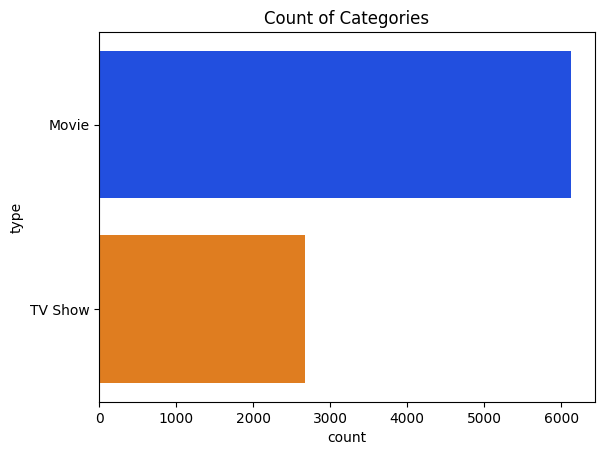

In [ ]:
#count the numnber of tv shows and moves
sns.countplot(df['type'], palette = 'bright')
plt.title('Count of Categories')
plt.show()

plot tv source and moves

/tmp/ipykernel_13891/1499385275.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = df.rating, palette = 'bright')


Text(0.5, 1.0, 'Ratings for movie and TV Sho')

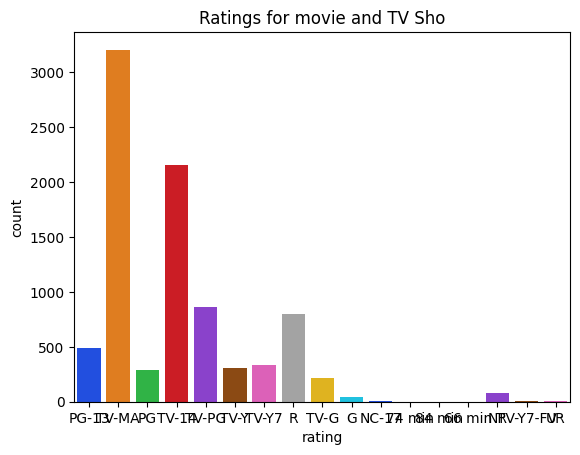

In [ ]:
sns.countplot(x = df.rating, palette = 'bright')
plt.title('Ratings for movie and TV Sho')

wordcloud -Word clouds (or tag clouds) are visual representations of text data, where the size of each word indicates its frequency or importance within a body of text. Larger, bolder words appear more frequently, offering an instant, engaging summary of key themes, sentiments, or topics.

In [ ]:
df = pd.read_csv('/netflix.csv')

In [ ]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year
df = df.dropna(subset=['year_added'])
df['year_added'] = df['year_added'].astype(int)

/tmp/ipykernel_13891/980934019.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['year_added'] = df['year_added'].astype(int)


In [ ]:
titles_per_year = df.groupby('year_added')['title'].count().reset_index()
titles_per_year = titles_per_year.rename(columns={'title': 'number_of_titles'})
display(titles_per_year)

,year_added,number_of_titles
0,2008,2
1,2009,2
2,2010,1
3,2011,13
4,2012,3
5,2013,10
6,2014,23
7,2015,73
8,2016,418
9,2017,1164


In [ ]:
#import the module
from wordcloud import WordCloud

In [ ]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


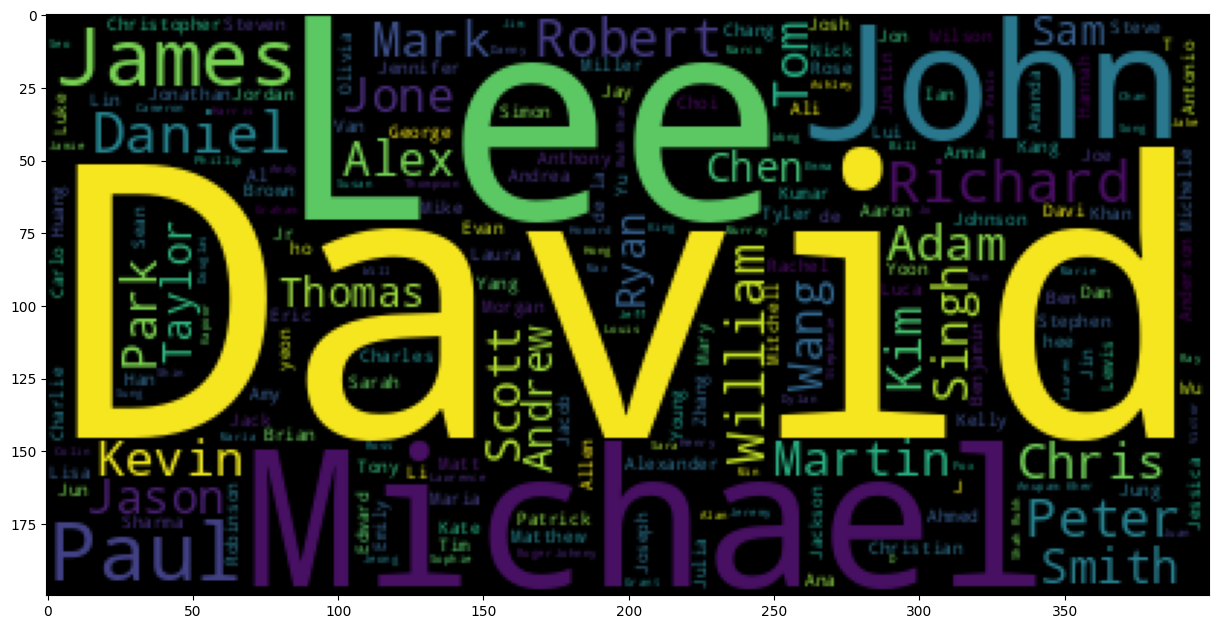

In [ ]:
# plot the word cloud for cast in the shows
plt.subplots(figsize = (15, 12))

# create an object fro word cloud module
wordcloud = WordCloud().generate(" ".join(df.cast.fillna('')))

plt.imshow(wordcloud)
plt.show()

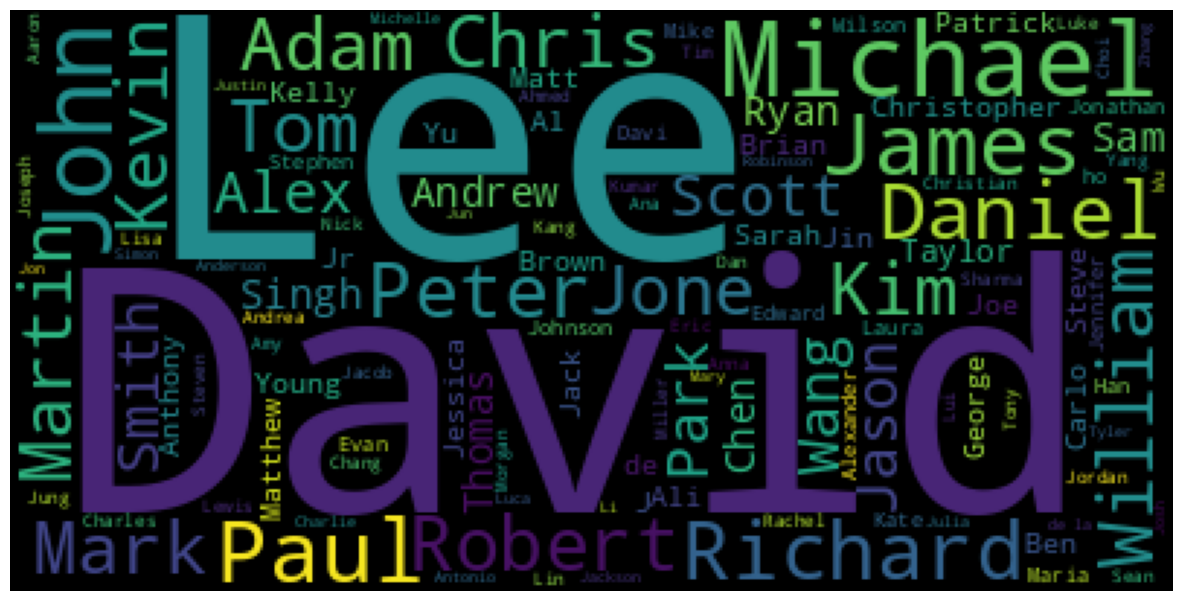

In [ ]:
# plot the word cloud for cast in the shows
plt.subplots(figsize = (15, 12))

# create an object fro word cloud module
wordcloud = WordCloud().generate(" ".join(df.cast.fillna('')))
# off the exis
plt.axis('off')
plt.imshow(wordcloud)
plt.show()

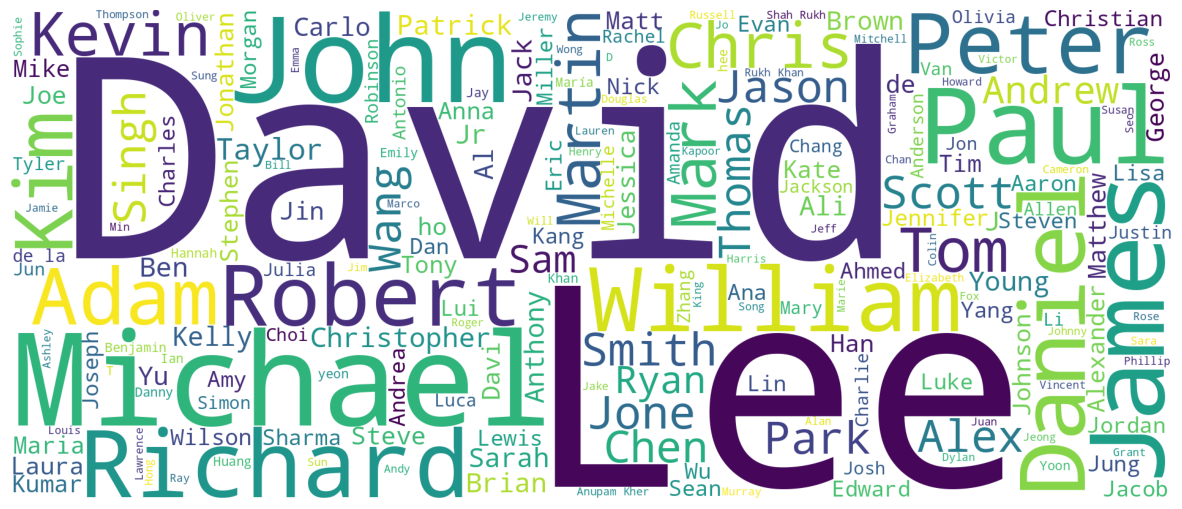

In [ ]:
# white backgroud
# plot the word cloud for cast in the shows
plt.subplots(figsize = (15, 12))

# create an object fro word cloud module
wordcloud = WordCloud(background_color = 'white',
                      width = 1900, height = 800).generate(" ".join(df.cast.fillna('')))
# off the exis
plt.axis('off')
plt.imshow(wordcloud)
plt.show()

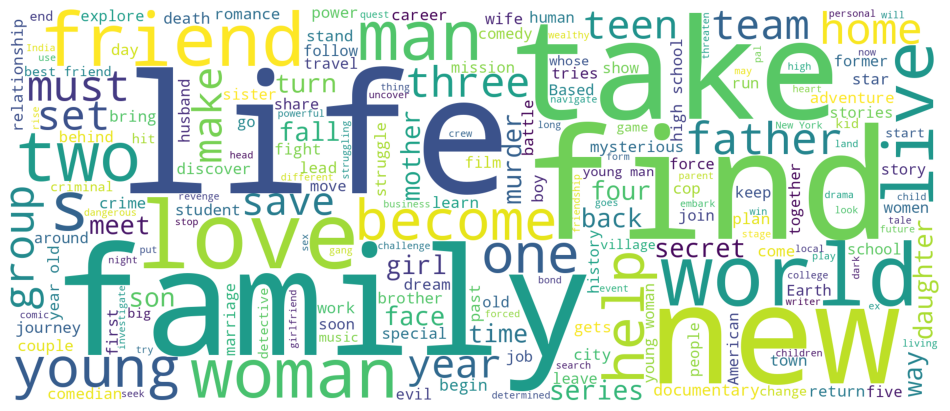

In [ ]:
# white backgroud
# plot the word cloud for cast in the shows
plt.subplots(figsize = (12, 8))

# create an object fro word cloud module
wordcloud = WordCloud(background_color = 'white',
                      width = 1900, height = 800).generate(" ".join(df.description))
# off the exis
plt.axis('off')
plt.imshow(wordcloud)
plt.show()